In [14]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
from pathlib import Path
import pandas as pd

data = Path('/kaggle/input/plantvillage-dataset')

paths = []

for image_type in ['color', 'grayscale', 'segmented']:
    type_dir = data / image_type

    for class_dir in type_dir.iterdir():
        if class_dir.is_dir():
            for img in class_dir.iterdir():
                paths.append((image_type, class_dir.name, img.name))

df = pd.DataFrame(paths, columns=['Image_Type', 'Class', 'Image'])

df.head()



,Image_Type,Class,Image
0,color,Tomato___Late_blight,781e93a9-2059-42de-8075-658033a6abf7___RS_Late...
1,color,Tomato___Late_blight,283ff0be-6e5e-4b4e-bf21-639780b77ffc___GHLB2 L...
2,color,Tomato___Late_blight,0db85707-41f9-42df-ba3b-842d14f00a68___GHLB2 L...
3,color,Tomato___Late_blight,078a999d-6e6f-427e-a1e6-80b4d2df2bae___GHLB2 L...
4,color,Tomato___Late_blight,3dcee9ed-43bb-45a9-8cff-641b3dd62179___RS_Late...


In [16]:
print('Count the number of images in the PlantVillage dataset')

print("Total Image Count :", len(df))

print("Total Disease Classes :", df['Class'].nunique(), "\n")

print("Number of images in each disease class:")
print(df['Class'].value_counts())



Count the number of images in the PlantVillage dataset
Total Image Count : 162916
Total Disease Classes : 38 

Number of images in each disease class:
Class
Orange___Haunglongbing_(Citrus_greening)              16521
Tomato___Tomato_Yellow_Leaf_Curl_Virus                16071
Soybean___healthy                                     15270
Peach___Bacterial_spot                                 6891
Tomato___Bacterial_spot                                6381
Tomato___Late_blight                                   5727
Squash___Powdery_mildew                                5505
Tomato___Septoria_leaf_spot                            5313
Tomato___Spider_mites Two-spotted_spider_mite          5028
Apple___healthy                                        4935
Tomato___healthy                                       4773
Blueberry___healthy                                    4506
Pepper,_bell___healthy                                 4434
Tomato___Target_Spot                                   4212
Gra

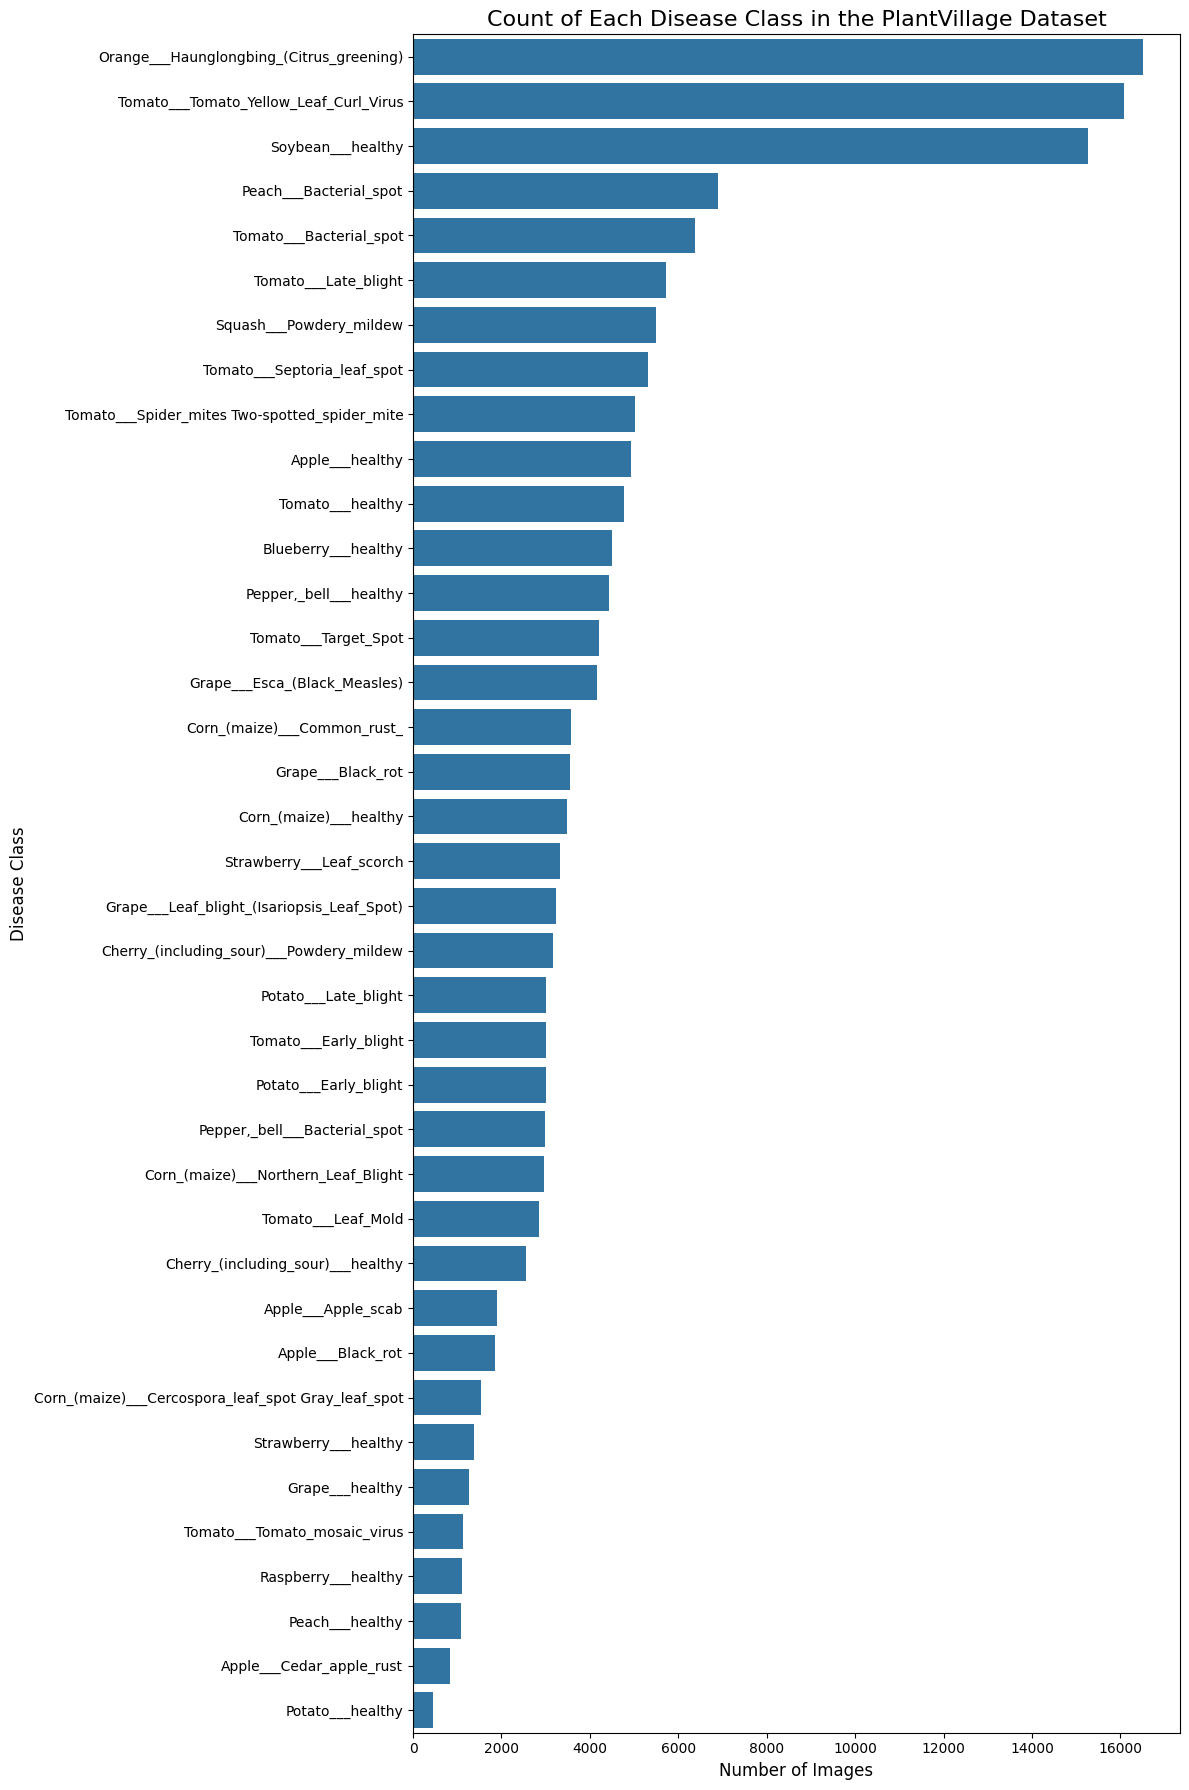

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 18))

sns.countplot(
    data=df,
    y='Class',
    order=df['Class'].value_counts().index
)

plt.title('Count of Each Disease Class in the PlantVillage Dataset', fontsize=16)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Disease Class', fontsize=12)

plt.tight_layout()
plt.show()





In [18]:
import plotly.express as px

# Create class distribution dataframe
Class_Id_Dist_Total = (
    df['Class']
    .value_counts()
    .reset_index()
)

Class_Id_Dist_Total.columns = ['Class', 'count']

# Plot pie chart
fig = px.pie(
    Class_Id_Dist_Total,
    names='Class',
    values='count',
    hole=0.5
)

fig.update_layout(
    title='Disease Class Distribution in the PlantVillage Dataset',
    title_x=0.5,
    font_size=14
)

fig.update_traces(textinfo='percent', textfont_size=11)
fig.show()



In [21]:
from concurrent.futures import ThreadPoolExecutor
from PIL import Image
import pandas as pd

def get_dims(image_path):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
        return height, width
    except:
        return None, None

paths = df['image_path'].tolist()

def process_all(paths, max_workers=8):
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        results = list(executor.map(get_dims, paths))
    return results

dims = process_all(paths)
df[['height', 'width']] = pd.DataFrame(dims, columns=['height','width'])

# Drop corrupted images
df = df.dropna(subset=['height','width']).reset_index(drop=True)

print(df.head())



  Image_Type                 Class  \
0      color  Tomato___Late_blight   
1      color  Tomato___Late_blight   
2      color  Tomato___Late_blight   
3      color  Tomato___Late_blight   
4      color  Tomato___Late_blight   

                                               Image  \
0  781e93a9-2059-42de-8075-658033a6abf7___RS_Late...   
1  283ff0be-6e5e-4b4e-bf21-639780b77ffc___GHLB2 L...   
2  0db85707-41f9-42df-ba3b-842d14f00a68___GHLB2 L...   
3  078a999d-6e6f-427e-a1e6-80b4d2df2bae___GHLB2 L...   
4  3dcee9ed-43bb-45a9-8cff-641b3dd62179___RS_Late...   

                                          image_path  height  width  
0  /kaggle/input/plantvillage-dataset/color/Tomat...     256    256  
1  /kaggle/input/plantvillage-dataset/color/Tomat...     256    256  
2  /kaggle/input/plantvillage-dataset/color/Tomat...     256    256  
3  /kaggle/input/plantvillage-dataset/color/Tomat...     256    256  
4  /kaggle/input/plantvillage-dataset/color/Tomat...     256    256  


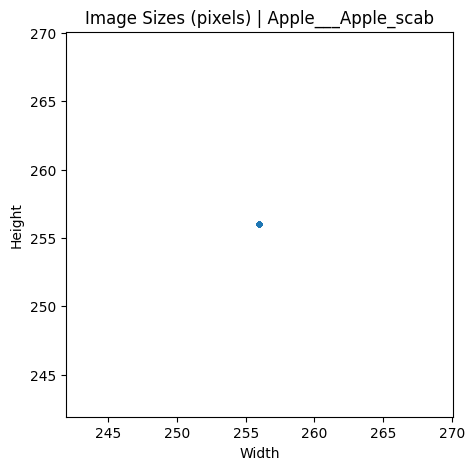

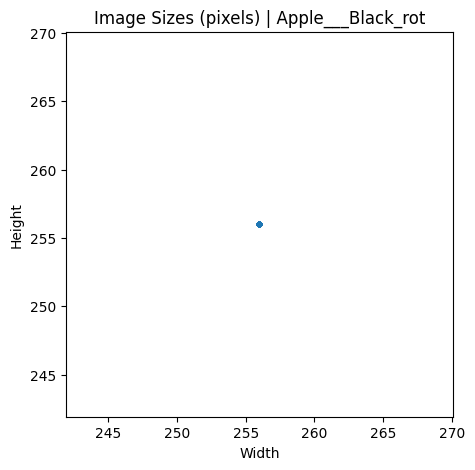

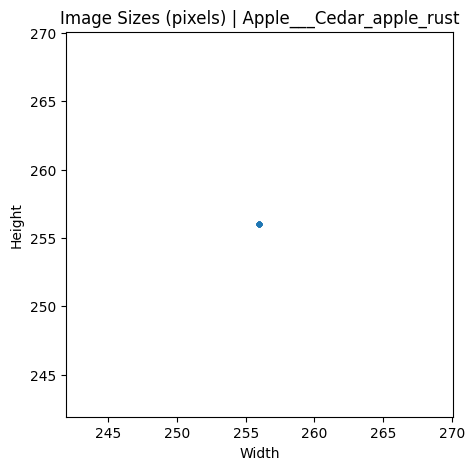

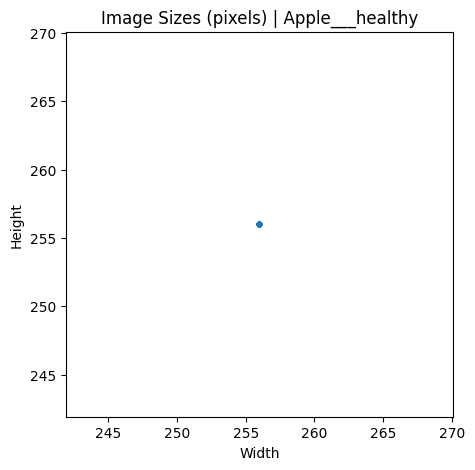

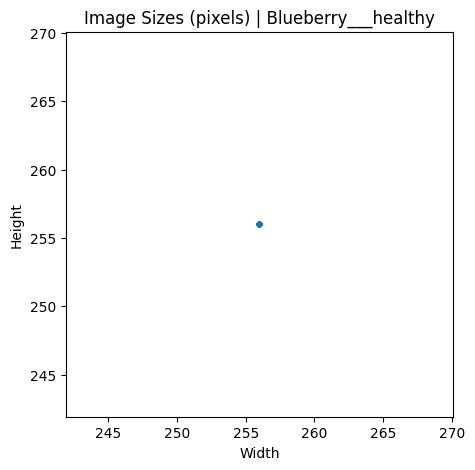

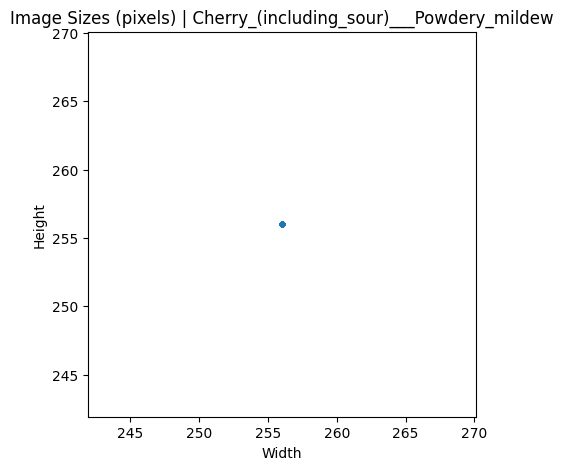

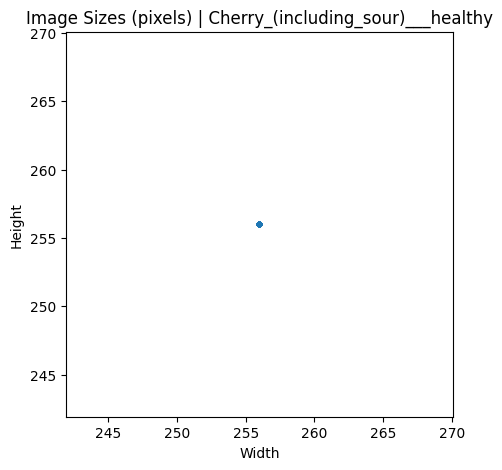

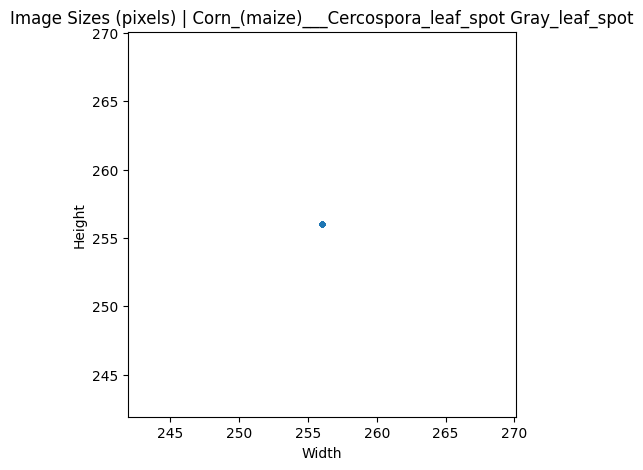

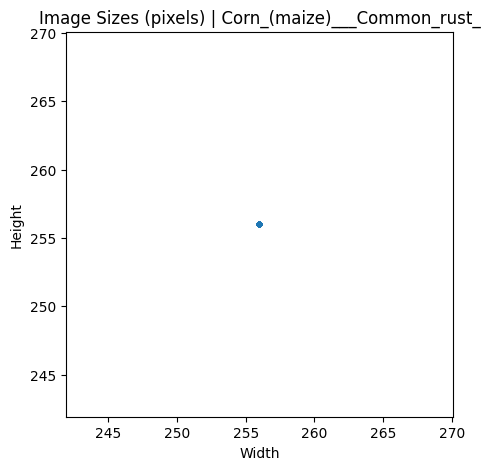

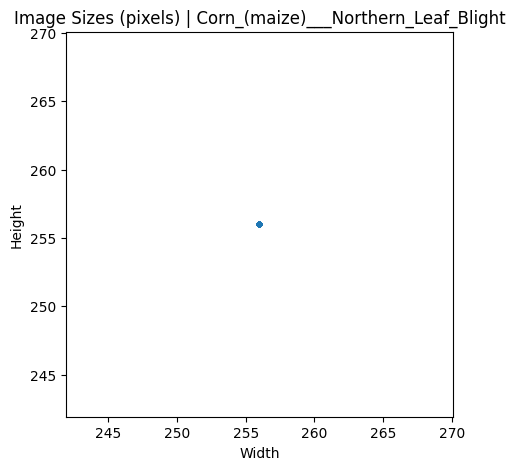

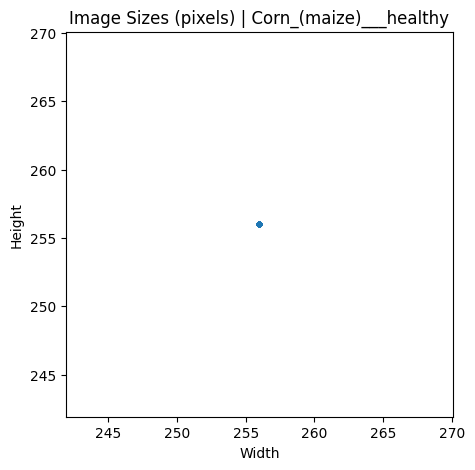

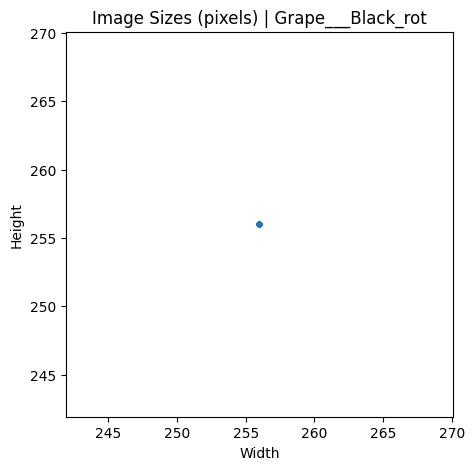

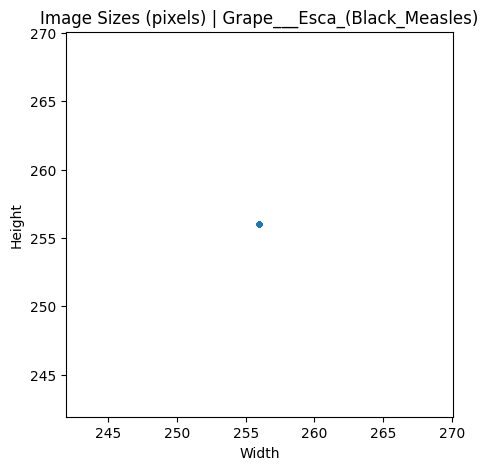

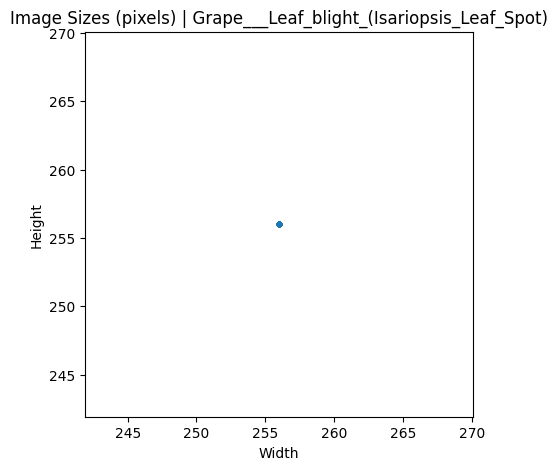

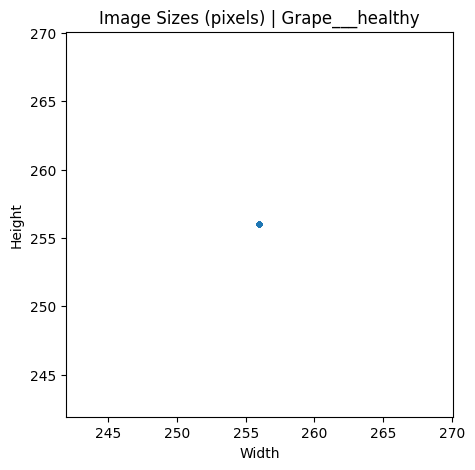

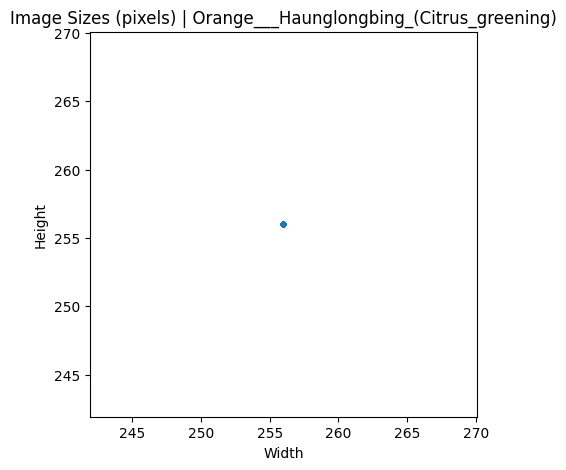

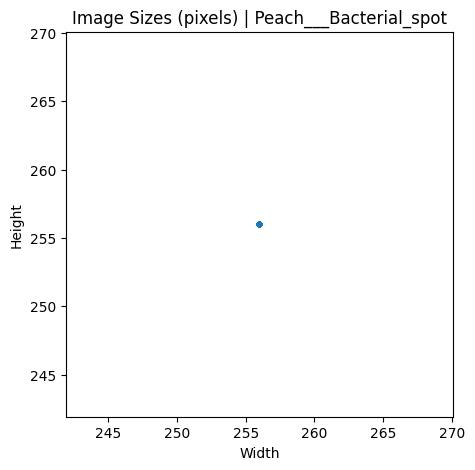

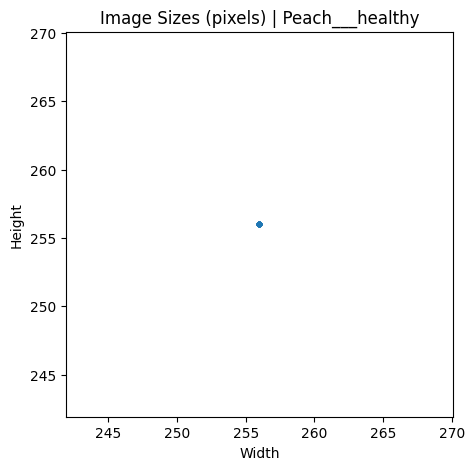

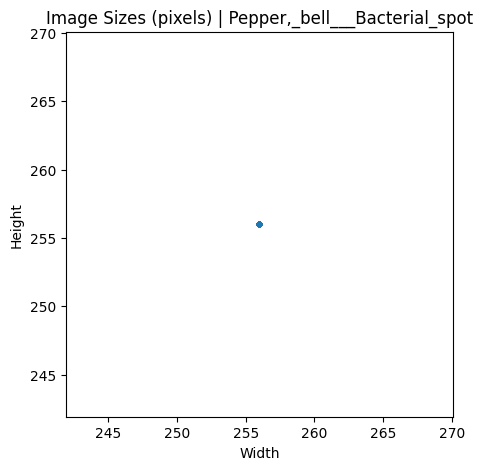

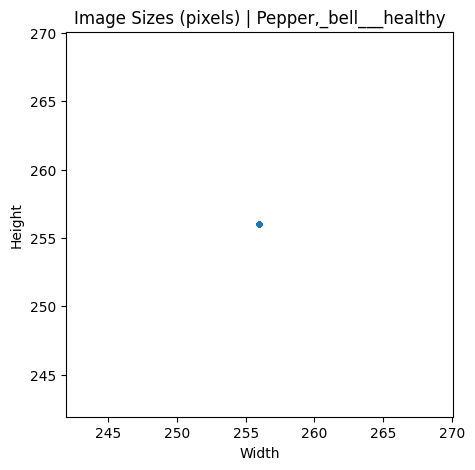

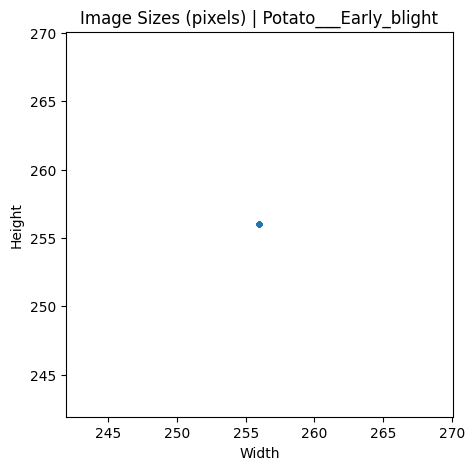

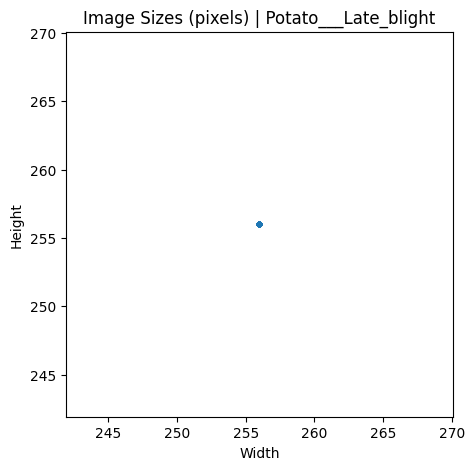

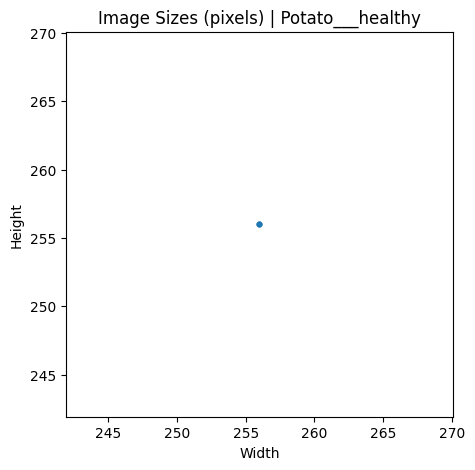

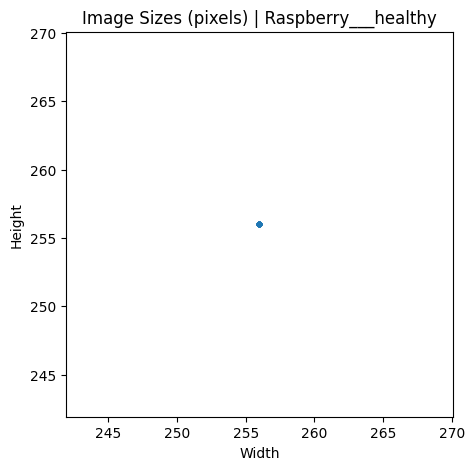

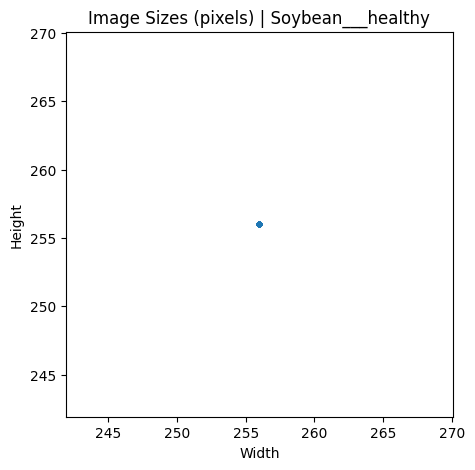

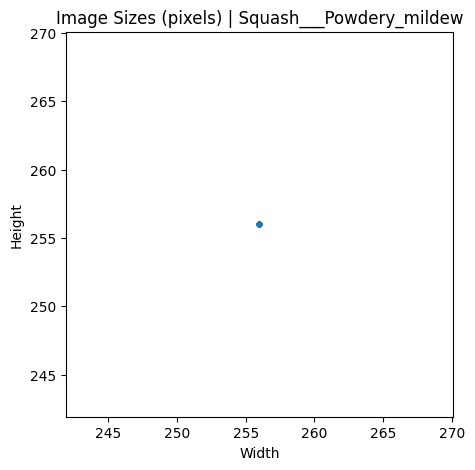

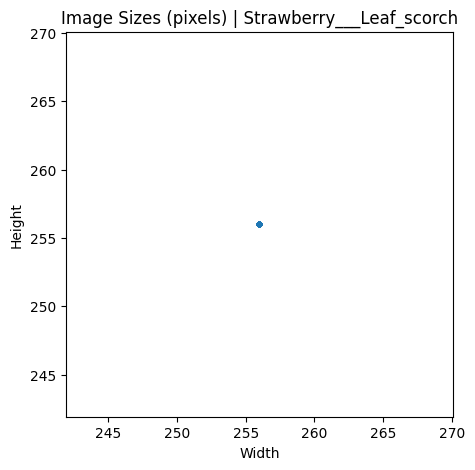

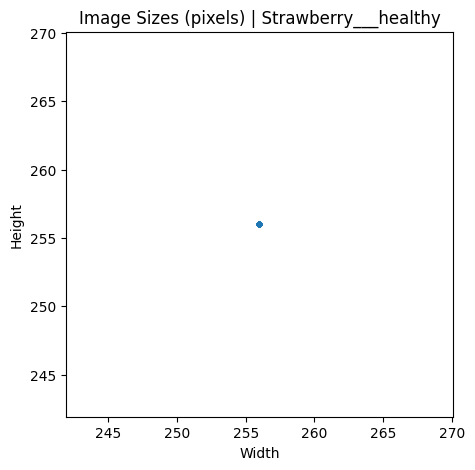

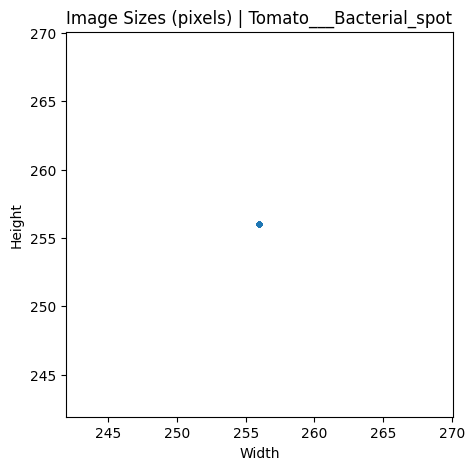

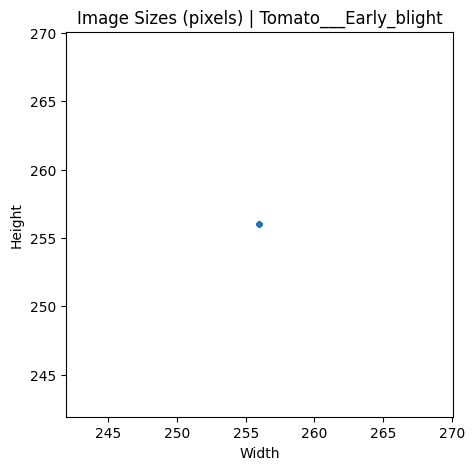

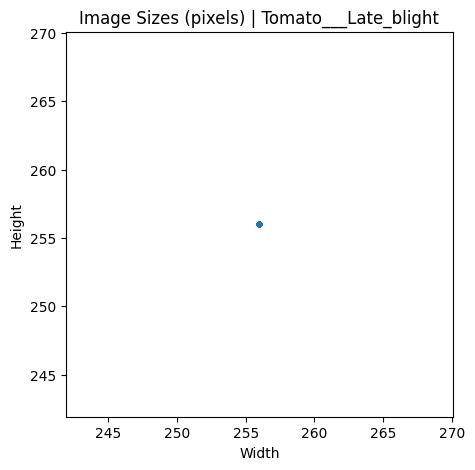

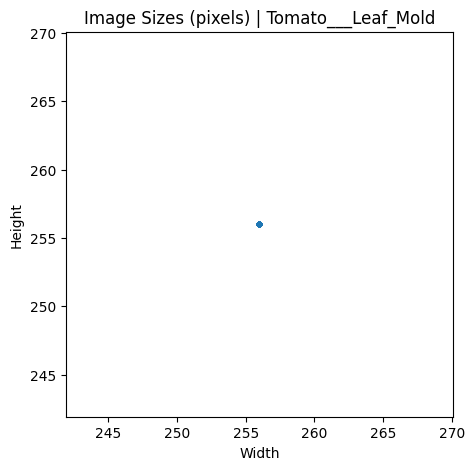

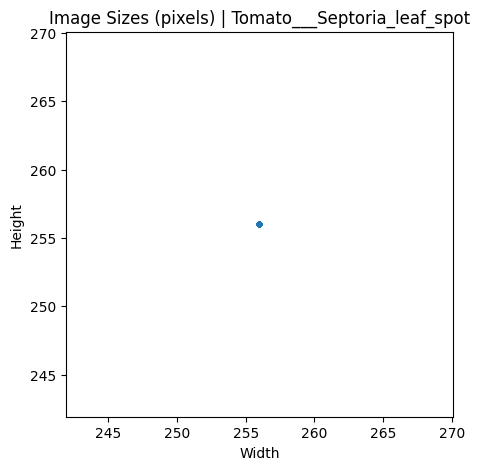

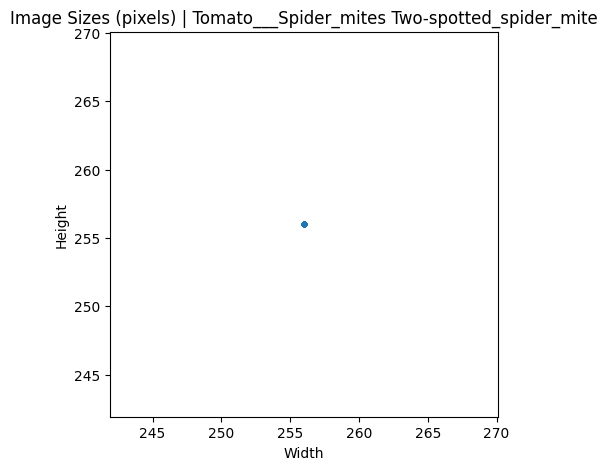

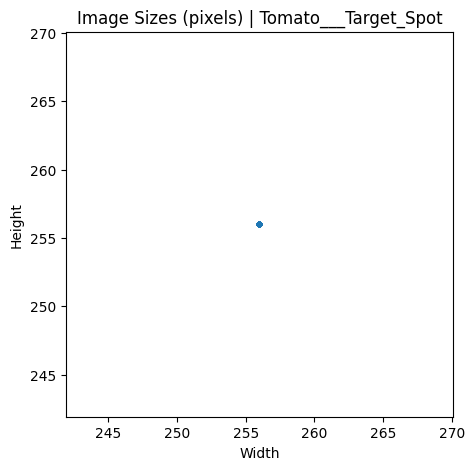

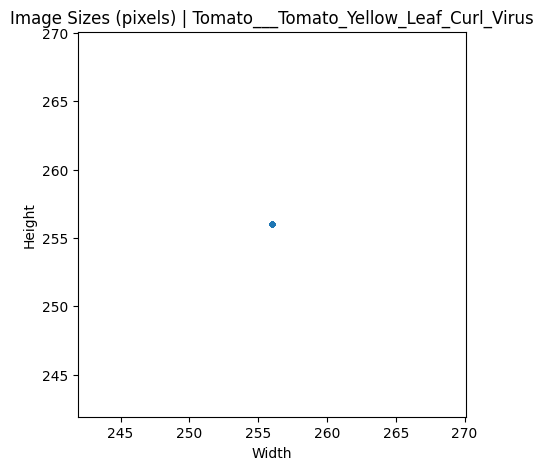

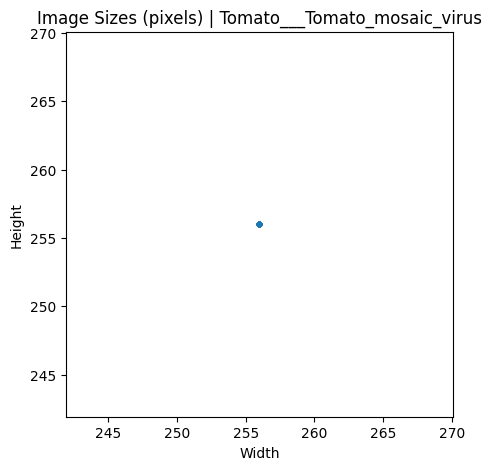

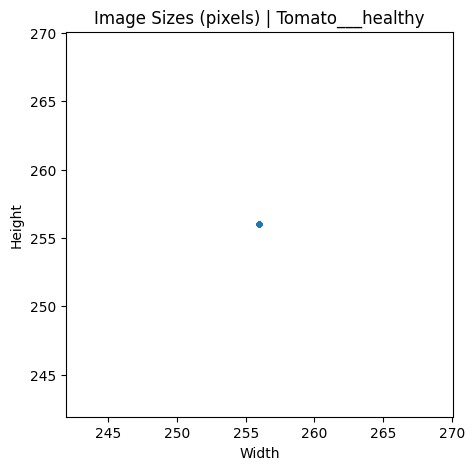

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def get_dims(image_path):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
        return height, width
    except:
        return None, None

sample_df = df.sample(n=5000, random_state=42).copy()

if 'height' not in sample_df or 'width' not in sample_df:
    dims = sample_df['image_path'].apply(lambda x: pd.Series(get_dims(x)))
    sample_df[['height', 'width']] = dims

for cls, subset in sample_df.groupby('Class'):
    plt.figure(figsize=(5,5))
    plt.scatter(subset['width'], subset['height'], s=10, alpha=0.4)
    plt.title(f'Image Sizes (pixels) | {cls}')
    plt.xlabel('Width')
    plt.ylabel('Height')
    plt.show()


**All images in the PlantVillage dataset are 256×256 pixels. That’s why the scatter plot shows a single point for every image. This happens because the dataset was preprocessed and resized to a uniform size, which is common for deep learning. It ensures all images can be fed directly into models without resizing. To check for corrupted images, you’d need to try opening them with a library like PIL.**

In [23]:
from PIL import Image
from tqdm import tqdm

corrupted = []

for path in tqdm(df['image_path'], desc="Checking images"):
    try:
        with Image.open(path) as img:
            img.verify()  # Verify image integrity
    except:
        corrupted.append(path)

print(f"Number of corrupted images: {len(corrupted)}")
if corrupted:
    print("Some corrupted images:", corrupted[:5])

Checking images: 100%|██████████| 162916/162916 [05:32<00:00, 490.32it/s]

Number of corrupted images: 0



**We checked all 162,916 images in the PlantVillage dataset for corruption by trying to open each image with PIL. The check found 0 corrupted images, which means every image is valid and can be used safely for analysis or training.Corrupted images are files that cannot be opened or read properly. This can happen if the file is incomplete, damaged, not actually an image, or has unreadable data. Corrupted images can cause errors during preprocessing or model training, so it’s important to detect and remove them if they exist.Since all images are 256×256 pixels and none are corrupted, the dataset is clean and ready for deep learning.**
